 # Projekt: Statistische Datenanalyse

Als Analyst für den E-Scooter-Verleihdienst GoFast war es meine Aufgabe, Daten von über 18.000 Fahrten und 1.565 Nutzern zu analysieren. Zur Verfügung standen zudem Informationen über das Vorhandensein oder Fehlen eines monatlichen Abonnements sowie die jeweiligen Nutzungsbedingungen für beide Nutzergruppen.

**Das Ziel** dieser Untersuchung ist die Überprüfung spezifischer Hypothesen, die zur Förderung des Geschäftswachstums beitragen können. Im Rahmen der Analyse werden folgende Schritte durchgeführt:

    1. Datenimport und -exploration: Einlesen der Datendateien und erste Sichtung der Informationen.

    2. Datenbereinigung: Identifizierung und Bearbeitung von potenziellen Fehlwerten und Dubletten.

    3. Explorative Datenanalyse (EDA): Gewinnung vertiefter Erkenntnisse über Nutzer und Fahrten (Häufigkeit der Städte, Alter der aktivsten Nutzer, Verhältnis von Abonnenten zu Nicht-Abonnenten sowie Dauer und Distanz der Fahrten).

    4. Datenzusammenführung: Verknüpfung der vorhandenen Tabellen zur Optimierung des Workflows sowie Aufteilung der Nutzer in zwei Gruppen (mit und ohne Abonnement) für vergleichende Analysen.

    5. Datenaggregation: Erstellung monatlicher Kennzahlen pro Nutzer (Anzahl der Fahrten, Gesamtdistanz und Fahrtdauer) sowie Berechnung des jeweils generierten monatlichen Umsatzes.

    6. Hypothesenprüfung: Statistische Untersuchung der geschäftsrelevanten Annahmen:

        - Höhere Fahrtdauer bei Nutzern mit Abonnement im Vergleich zu Nutzern ohne Abonnement.
        - Entspricht die durchschnittliche Distanz einer Einzelfahrt bei Abonnenten genau 3.130 Metern?
        - Generieren Nutzer mit Abonnement einen höheren monatlichen Umsatz?

    7. Modellierung von Wahrscheinlichkeitsverteilungen:
    Ermittlung der Anzahl benötigter Gutscheincodes, um mit einer Wahrscheinlichkeit von 95 % mindestens 100 Abonnement-Verlängerungen zu erzielen.
    Berechnung der Wahrscheinlichkeit, dass von 1 Million versendeten Push-Benachrichtigungen maximal 399.500 von den Nutzern geöffnet werden.

In [1]:
#Import der Bibliotheken
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
from scipy.stats import binom

#### Schritt 1: Datenimport

Hier wurden die Datensätze importiert und eine erste Übersicht über deren Struktur und Inhalte gewonnen.

In [2]:
users = pd.read_csv('C:/datasets/users_go.csv')
rides = pd.read_csv('C:/datasets/rides_go.csv')
subscriptions = pd.read_csv('C:/datasets/subscriptions_go.csv')

In [3]:
display(users.head(10))

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


In [4]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [5]:
display(rides.head(10))

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


In [6]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [7]:
display(subscriptions)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


Nach der ersten Datenanalyse lassen sich folgende Schlussfolgerungen ziehen.
Im Rahmen der Arbeit stehen drei Tabellen mit unterschiedlichen Informationen zur Verfügung:
Die erste Tabelle enthält Daten zu den Nutzern selbst, darunter Name, Alter, Stadt sowie Angaben zum Vorhandensein eines Abonnements. Sie umfasst 1.565 Zeilen.
Der zweite DataFrame enthält Informationen zu den monatlichen Fahrten jedes Nutzers anhand seiner Identifikationsnummer. Insgesamt sind 18.068 Fahrten erfasst.
Die letzte Tabelle enthält Informationen zu den Mietbedingungen für E-Scooter mit und ohne Abonnement.
Im Rahmen der Datenvorverarbeitung ist es erforderlich, die Daten auf fehlende Werte und Duplikate zu überprüfen sowie das Datenformat in der Spalte mit dem Fahrtdatum anzupassen.

#### Schritt 2: Datenvorverarbeitung

Der Datentyp der Spalte mit dem Fahrtdatum wird in das Format „datetime“ konvertiert. Zusätzlich wird eine neue Spalte ergänzt, die die Monatsnummer der jeweiligen Fahrt enthält.

In [9]:
rides['date'] = pd.to_datetime(rides['date'], format = '%Y-%m-%d')
display(rides.date.dtype)

dtype('<M8[ns]')

In [10]:
rides['month'] = pd.DatetimeIndex(rides['date']).month
display(rides.head(5))

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Prüfung der DataFrames auf fehlende Werte.

In [11]:
display(users.isna().sum())

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [12]:
display(rides.isna().sum())

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [13]:
display(subscriptions.isna().sum())

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Im ersten DataFrame wurde die Anzahl der Duplikate überprüft und vorhandene Duplikate wurden entfernt.

In [14]:
duplicates = users.duplicated().sum()
print('Ursprüngliche Anzahl der Duplikate:', duplicates)
users = users.drop_duplicates().reset_index(drop=True)

print('Anzahl der Duplikate nach deren Entfernung:', users.duplicated().sum())

Ursprüngliche Anzahl der Duplikate: 31
Anzahl der Duplikate nach deren Entfernung: 0


In [15]:
display(rides.duplicated().sum())

0

In den geladenen DataFrames wurden keine fehlenden Werte festgestellt, was die Arbeit mit den Daten erleichtert hat. Duplikate wurden nur in der ersten Tabelle mit den Informationen zu den Nutzern des Services gefunden. In diesem Fall war die beste Lösung, diese zu entfernen, da für die Analyse keine mehrfachen Zeilen mit identischen Daten für denselben Nutzer erforderlich sind.

#### Schritt 3: Explorative Datenanalyse

Darstellung der Häufigkeit der in den Daten vorkommenden Städte.

In [16]:
city_info = users.pivot_table(index = 'city', values = 'user_id', aggfunc = 'count').reset_index().rename(columns={'user_id':'count'}).sort_values(by = 'count', ascending = False)
display(city_info.head(10))

,city,count
4,Пятигорск,219
0,Екатеринбург,204
5,Ростов-на-Дону,198
1,Краснодар,193
6,Сочи,189
3,Омск,183
7,Тюмень,180
2,Москва,168


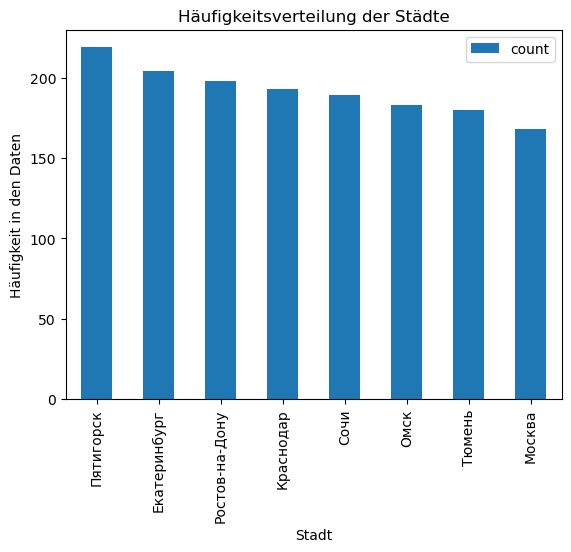

In [17]:
city_info.plot(x = 'city', y = 'count', kind = 'bar', title = 'Häufigkeitsverteilung der Städte', xlabel='Stadt', ylabel='Häufigkeit in den Daten')
plt.show()

Die meisten Fahrten fanden in Pjatigorsk statt, während in anderen Städten, wie beispielsweise Moskau, deutlich weniger Fahrten verzeichnet wurden.

In [18]:
#Anteil der Nutzer mit versus ohne Abonnement
subscription_rate = users.pivot_table(index = 'subscription_type', values = 'user_id', aggfunc = 'count').reset_index().rename(columns={'user_id':'count'})
subscription_rate['share'] = subscription_rate['count'] / (subscription_rate.loc[0, 'count'] + subscription_rate.loc[1, 'count'])
display(subscription_rate)

,subscription_type,count,share
0,free,835,0.544329
1,ultra,699,0.455671


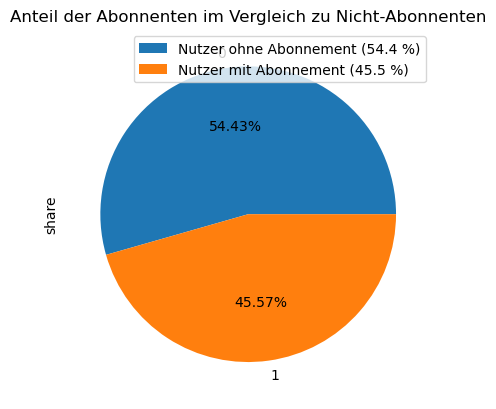

In [19]:
subscription_rate['share'].plot(kind='pie', autopct='%1.2f%%')
labels = [r'Nutzer ohne Abonnement (54.4 %)', r'Nutzer mit Abonnement (45.5 %)']
plt.legend(labels, loc='upper right')
plt.title('Anteil der Abonnenten im Vergleich zu Nicht-Abonnenten')
plt.show()

Bei dem Service ist die Anzahl der Nutzer mit und ohne Abonnement vergleichbar, wobei die Nutzer ohne Abonnement einen leichten Überhang darstellen.

In [20]:
#Altersverteilung der Nutzer
users_age = users.pivot_table(index = 'age', values = 'user_id', aggfunc = 'count').reset_index().rename(columns={'user_id':'count'}).sort_values(by = 'age', ascending = False).reset_index(drop=True)
display(users_age)

,age,count
0,43,1
1,39,1
2,38,3
3,37,2
4,36,6
5,35,15
6,34,19
7,33,39
8,32,41
9,31,48


count    29.000000
mean     26.103448
std       8.706914
min      12.000000
25%      19.000000
50%      26.000000
75%      33.000000
max      43.000000
Name: age, dtype: float64

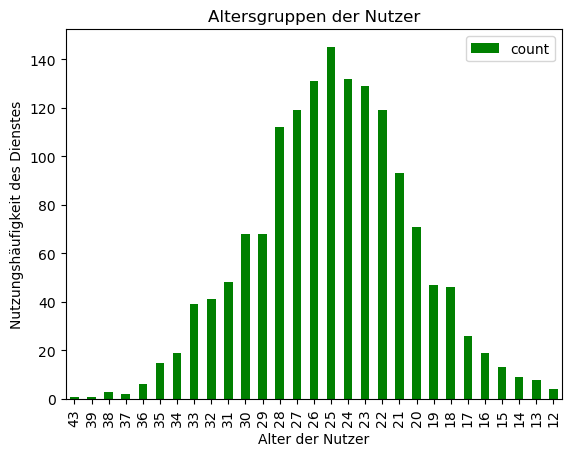

In [21]:
users_age.plot(x = 'age', y = 'count', kind = 'bar', color = 'g', title = 'Altersgruppen der Nutzer', xlabel='Alter der Nutzer', ylabel='Nutzungshäufigkeit des Dienstes')
display(users_age['age'].describe())

Es erscheint logisch, dass der Höhepunkt der Nutzung des E-Scooter-Services bei Nutzern im Alter von 20 bis 30 Jahren liegt, mit einem allmählichen Rückgang der Aktivität in beide Richtungen (von 12 bis 20 und von 30 bis 43 Jahren). Das Durchschnittsalter der Nutzer beträgt, wie aus der Datenbeschreibung ersichtlich, 26 Jahre, und 75 % der Nutzer liegen im Alter bis 33 Jahre.

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

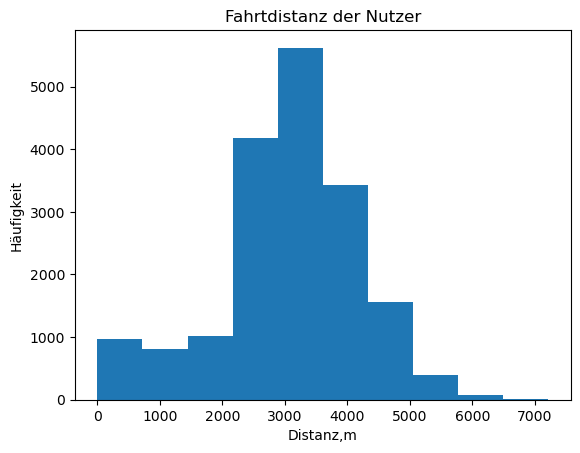

In [22]:
#Fahrtdistanz pro Einzelreise
display(rides['distance'].describe())
ax = rides['distance'].plot(kind='hist')
ax.set_xlabel('Distanz,m')
ax.set_ylabel('Häufigkeit')
plt.title('Fahrtdistanz der Nutzer')
plt.show()

Am häufigsten legten die Nutzer eine Strecke von etwa 2.900 bis 3.700 Metern zurück. Außerdem lässt sich schließen, dass kurze Fahrten (bis 5 km) bei den Kunden beliebter sind.

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

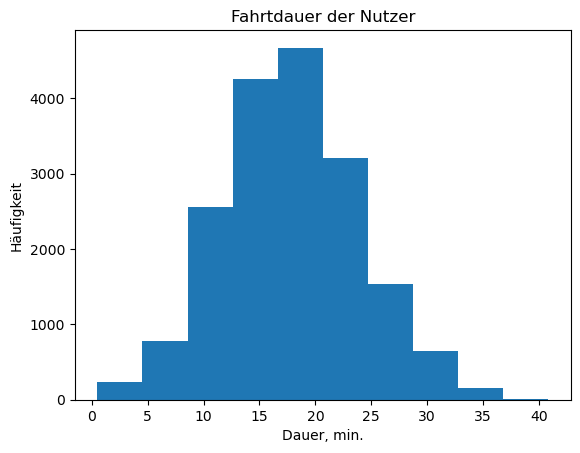

In [23]:
#продолжительность поездок
display(rides['duration'].describe())
ax1 = rides['duration'].plot(kind='hist')
ax1.set_xlabel('Dauer, min.')
ax1.set_ylabel('Häufigkeit')
plt.title('Fahrtdauer der Nutzer')
plt.show()

Aus der Grafik geht hervor, dass Fahrten mit einer Dauer von etwa 13 bis 22 Minuten am häufigsten vorkommen. Fahrten mit kürzerer oder längerer Dauer nehmen hingegen kontinuierlich ab, je weiter sie vom Durchschnittswert abweichen.

Ergebnisse der explorativen Datenanalyse (EDA)
Im Rahmen der explorativen Datenanalyse wurden folgende Muster identifiziert und visualisiert:
    1. Häufigkeit der Städte: Verteilung der Kunden nach Standorten – Pjatigorsk belegt den ersten Platz, während Moskau an letzter Stelle steht.

    2. Nutzeraktivität nach Alter: Die aktivsten Nutzer des E-Scooter-Verleihs liegen erwartungsgemäß in der Altersgruppe zwischen 20 und 30 Jahren (Durchschnittsalter: 26 Jahre).

    3. Abonnement-Status: Vergleich des Anteils von Nutzern mit und ohne Abonnement – die Anzahl der Nutzer ohne Abo liegt etwas höher.

    4. Fahrtdaten (Distanz und Dauer): Die meisten Fahrten belaufen sich im Durchschnitt auf 3 km und dauern etwa 18 Minuten. Deutlich kürzere oder längere Fahrten treten seltener auf.

#### Schritt 4: Zusammenführen der Daten (Data Merging)

In [24]:
full_data = users.merge(rides, on = 'user_id')
display(full_data.head(20))
display(full_data.shape[0])

,user_id,name,age,city,subscription_type,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11


18068

In [25]:
full_data = full_data.merge(subscriptions, on = 'subscription_type')
display(full_data.head(10))
display(full_data.shape[0])

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11,6,0,199


18068

Es wurde ein gemeinsamer DataFrame erstellt, der alle Fahrtdaten der Nutzer enthält. Im nächsten Schritt erfolgt die Aufteilung in zwei Kategorien: Nutzer mit und ohne Abonnement.

In [26]:
#Nutzer ohne Abonnement
full_data_free = full_data.query('subscription_type == "free"')
display(full_data_free.head(10))
display(full_data_free.shape[0])

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0
6505,700,Айдар,22,Омск,free,4342.002254,22.368009,2021-02-23,2,8,50,0
6506,700,Айдар,22,Омск,free,3798.334905,18.243756,2021-03-03,3,8,50,0
6507,700,Айдар,22,Омск,free,2984.551206,15.424899,2021-04-09,4,8,50,0
6508,700,Айдар,22,Омск,free,3360.107141,16.765497,2021-06-12,6,8,50,0
6509,700,Айдар,22,Омск,free,2567.543847,11.312160,2021-06-23,6,8,50,0


11568

In [27]:
#Nutzer mit Abonnement
full_data_ultra = full_data.query('subscription_type == "ultra"')
display(full_data_ultra.head(10))
display(full_data_ultra.shape[0])

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11,6,0,199


6500

In diesem Schritt wurden die Daten in einem Dataframe zusammengeführt und anschließend entsprechend dem Vorhandensein oder Fehlen eines Abonnements bei den Nutzern in zwei Gruppen aufgeteilt. In der abschließenden Gesamttabelle stimmt die Anzahl der Zeilen mit der ursprünglichen Anzahl überein – 18.068.

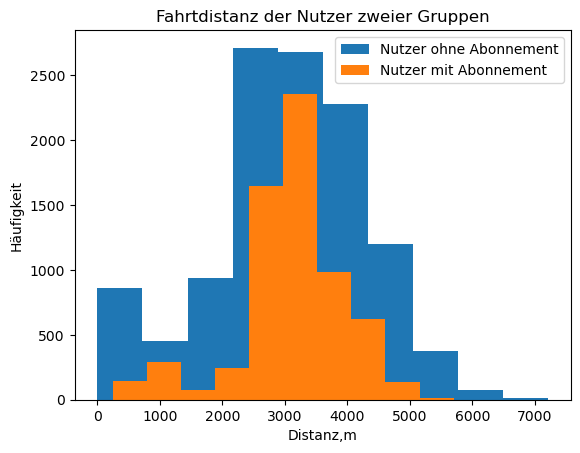

In [28]:
#Дистанция
ax2 = full_data_free['distance'].plot(kind='hist')
ax2 = full_data_ultra['distance'].plot(kind='hist')
ax2.set_xlabel('Distanz,m')
ax2.set_ylabel('Häufigkeit')
plt.title('Fahrtdistanz der Nutzer zweier Gruppen')
labels1 = [r'Nutzer ohne Abonnement', r'Nutzer mit Abonnement']
plt.legend(labels1, loc='upper right')
plt.show()


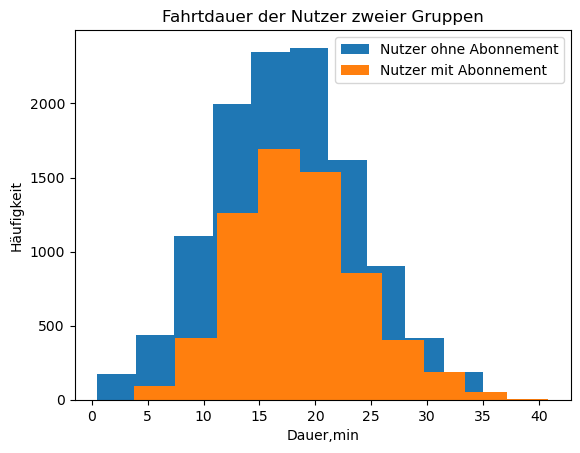

In [29]:
#Визуализация продолжительности
ax3 = full_data_free['duration'].plot(kind='hist')
ax3 = full_data_ultra['duration'].plot(kind='hist')
ax3.set_xlabel('Dauer,min')
ax3.set_ylabel('Häufigkeit')
plt.title('Fahrtdauer der Nutzer zweier Gruppen')
labels1 = [r'Nutzer ohne Abonnement', r'Nutzer mit Abonnement']
plt.legend(labels1, loc='upper right')
plt.show()

In der Phase der Datenzusammenführung wurden alle Dataframes mit Informationen über die Nutzer des Dienstes und ihre Fahrten aggregiert sowie zwei neue Tabellen für die verschiedenen Nutzergruppen erstellt. Auf Grundlage dieser Tabellen werden im weiteren Verlauf die notwendigen Berechnungen zur Hypothesenprüfung durchgeführt.
Zudem wurden vergleichende Daten der beiden Nutzergruppen bezüglich der Dauer und Distanz ihrer Fahrten visualisiert. Es lässt sich feststellen, dass die am häufigsten vorkommende Fahrtdistanz bei Nutzern mit Abonnement höher ist als der entsprechende Wert bei Nutzern der anderen Gruppe. Hinsichtlich der Fahrtdauer ähneln sich beide Nutzergruppen, jedoch ist die Bandbreite der Werte bei Nutzern ohne Abonnement größer.

#### Schritt 5: Berechnung des Umsatzes

Das Ziel dieses Schrittes ist die Berechnung des monatlichen Umsatzes, den jeder Nutzer des Dienstes generiert hat.

In [30]:
rides['duration'] = np.ceil(rides['duration'])
display(rides.head(10))

,user_id,distance,duration,date,month
0,1,4409.919140,26.0,2021-01-01,1
1,1,2617.592153,16.0,2021-01-18,1
2,1,754.159807,7.0,2021-04-20,4
3,1,2694.783254,19.0,2021-08-11,8
4,1,4028.687306,27.0,2021-08-28,8
5,1,2770.890808,17.0,2021-10-09,10
6,1,3039.020292,15.0,2021-10-19,10
7,1,2842.118050,24.0,2021-11-06,11
8,1,3412.690668,16.0,2021-11-14,11
9,1,748.690645,16.0,2021-11-22,11


In [31]:
#Erstellung einer Tabelle mit aggregierten Daten zu den Nutzerfahrten
users_rides = full_data.pivot_table(index = ['user_id','month', 'subscription_type'], values = ['distance', 'duration'], aggfunc = ['sum', 'count']).reset_index()
users_rides.columns = ['user_id', 'month', 'subscription_type', 'total_distance', 'total_duration', 'total_rides', 'total_rides2']
users_rides = users_rides.drop('total_rides2', axis = 1)
users_rides['total_duration'] = np.ceil(users_rides['total_duration'])
display(users_rides.tail(10))

,user_id,month,subscription_type,total_distance,total_duration,total_rides
11321,1533,8,free,4581.943632,22.0,1
11322,1533,11,free,3414.448028,26.0,1
11323,1534,1,free,4678.415899,16.0,1
11324,1534,2,free,2103.914120,14.0,1
11325,1534,4,free,3434.290912,15.0,1
11326,1534,6,free,3409.468534,25.0,2
11327,1534,8,free,7622.453034,48.0,2
11328,1534,9,free,4928.173852,23.0,1
11329,1534,11,free,13350.015305,77.0,4
11330,1534,12,free,2371.711192,16.0,1


In [32]:
#Umsatzberechnung
users_rides['minute_price'] = np.where(users_rides.subscription_type == 'ultra', 6, 8)
users_rides['start_ride_price'] = np.where(users_rides.subscription_type == 'ultra', 0, 50)
users_rides['subscription_fee'] = np.where(users_rides.subscription_type == 'ultra', 199, 0)
users_rides['revenue'] = users_rides['start_ride_price'] * users_rides['total_rides'] + users_rides['minute_price'] * users_rides['total_duration'] + users_rides['subscription_fee']
display(users_rides.tail(10))

,user_id,month,subscription_type,total_distance,total_duration,total_rides,minute_price,start_ride_price,subscription_fee,revenue
11321,1533,8,free,4581.943632,22.0,1,8,50,0,226.0
11322,1533,11,free,3414.448028,26.0,1,8,50,0,258.0
11323,1534,1,free,4678.415899,16.0,1,8,50,0,178.0
11324,1534,2,free,2103.914120,14.0,1,8,50,0,162.0
11325,1534,4,free,3434.290912,15.0,1,8,50,0,170.0
11326,1534,6,free,3409.468534,25.0,2,8,50,0,300.0
11327,1534,8,free,7622.453034,48.0,2,8,50,0,484.0
11328,1534,9,free,4928.173852,23.0,1,8,50,0,234.0
11329,1534,11,free,13350.015305,77.0,4,8,50,0,816.0
11330,1534,12,free,2371.711192,16.0,1,8,50,0,178.0


#### Schritt 6: Statistische Hypothesenprüfung

Nullhypothese (H0): Die durchschnittliche Fahrtdauer der Nutzer mit Abonnement entspricht der der Nutzer aus der anderen Gruppe.

Alternativhypothese (H1): Die durchschnittliche Fahrtdauer der Nutzer mit Abonnement ist höher.

H0: µ1 = µ2
H1: µ1 > µ2

In [33]:
#Ist die Fahrtdauer bei Nutzern mit Abonnement höher
print(np.mean(full_data_ultra['duration']))
print(np.mean(full_data_free['duration']))
alpha = 0.05
results = st.ttest_ind(full_data_ultra['duration'], full_data_free['duration'], alternative = 'greater')
print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Die Nullhypothese wird verworfen')
else:
    print('Die Nullhypothese konnte nicht verworfen werden')


18.54198516280583
17.39090929866399
p-value: 1.2804098316645618e-34
Die Nullhypothese wird verworfen


Aufgrund der durchgeführten Analyse können wir die Hypothese, dass die durchschnittliche Fahrtdauer von Nutzern mit Abonnement der Fahrtdauer von Nutzern ohne Abonnement entspricht, zugunsten der Alternativhypothese verwerfen, wonach dieser Wert bei Nutzern mit Abonnement höher ist.

Nullhypothese (H0): Die durchschnittliche Fahrtstrecke der Nutzer mit Abonnement beträgt 3130 Meter.
Alternativhypothese (H1): Nutzer mit Abonnement legen im Durchschnitt mehr als 3130 Meter pro Fahrt zurück.

H0: µ1 = 3130
H1: µ1 > 3130

In [34]:
#Die durchschnittliche Distanz, die Nutzer mit Abonnement pro Fahrt zurücklegen, überschreitet 3130 Meter nicht
alpha = 0.05
value = 3130
results = st.ttest_1samp(full_data_ultra['distance'], value, alternative='greater')
print(results.pvalue)
if results.pvalue < alpha:
    print('Die Nullhypothese wird verworfen')
else:
    print('Die Nullhypothese konnte nicht verworfen werden')

0.9195368847849785
Die Nullhypothese konnte nicht verworfen werden


Wir verwerfen die Nullhypothese nicht, dass die durchschnittliche Fahrtdistanz der Nutzer mit Abonnement 3130 Meter beträgt.

Ответ Gemini
Nullhypothese (H0): Der monatliche Umsatz der Nutzer mit Abonnement entspricht dem der Nutzer aus der Gruppe ohne Abonnement.
Alternativhypothese (H1): Nutzer mit Abonnement generieren einen höheren monatlichen Umsatz als Nutzer ohne Abonnement.

H0: µ1 = µ2 H1: µ1 > µ2

In [35]:
#Der monatliche Umsatz der Nutzer mit Abonnement ist höher als der Umsatz der Nutzer ohne Abonnement
users_rides_ultra = users_rides[users_rides['subscription_type'] == 'ultra']
users_rides_free = users_rides[users_rides['subscription_type'] == 'free']
alpha = 0.05
results = st.ttest_ind(users_rides_ultra['revenue'], users_rides_free['revenue'], alternative = 'greater')
print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print('Die Nullhypothese wird verworfen')
else:
    print('Die Nullhypothese konnte nicht verworfen werden')

p-value: 2.8130926188487286e-35
Die Nullhypothese wird verworfen


Wir verwerfen die Nullhypothese, dass der Umsatz von Nutzern mit und ohne Abonnement gleich ist.

Frage: Welcher Test wird benötigt, um die Hypothese zu prüfen, dass nach einem Server-Update für die Interaktion mit der mobilen App die Anzahl der Support-Anfragen gesunken ist?

Antwort: Um diese Hypothese zu prüfen, wäre ein t-Test für abhängige (gepaarte) Stichproben erforderlich, der Daten derselben Nutzer vor und nach dem Update vergleicht. Hierfür kann in Python die Methode scipy.stats.ttest_rel() verwendet werden, indem ihr die Datensätze von „vorher“ und „nachher“ als Argumente übergeben werden. Mit ihrer Hilfe lässt sich eine rechtsseitige Hypothese prüfen: dass der wahre Mittelwert der Grundgesamtheit vor der Änderung höher ist als der Wert nach der Änderung.

#### Шаг 7. Распределения

<BarContainer object of 101 artists>

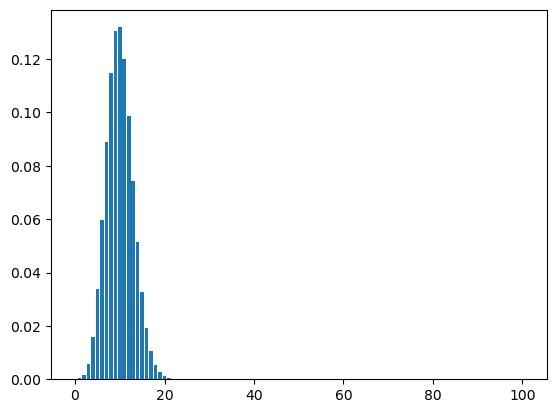

In [36]:
#Eine Wahrscheinlichkeitsverteilung grafisch darstellen

n = 100
p = 0.1

distr = []

for k in range(0, n + 1):
    current_value = binom.pmf(k, n, p)
    distr.append(current_value)
    
plt.bar(range(0, n + 1), distr)



Wie in der Grafik zu sehen ist, ist die Verteilung bei 100 Versuchen und einer Erfolgswahrscheinlichkeit von 10 % nach links verschoben. Das bedeutet, dass es am wahrscheinlichsten ist, bis zu 20 erfolgreiche Ergebnisse zu erzielen. 

<BarContainer object of 101 artists>

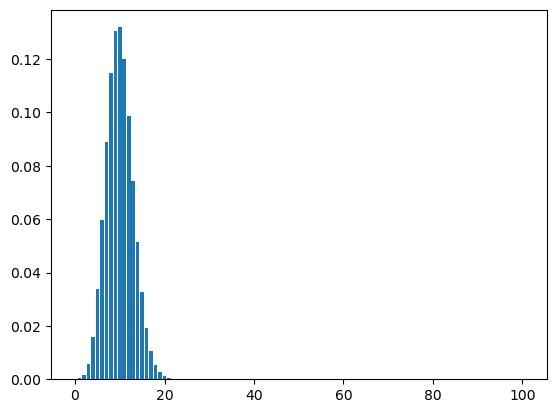

In [37]:
#Eine Wahrscheinlichkeitsverteilung grafisch darstellen

n = 100
p = 0.1

distr = []

for k in range(0, n + 1):
    current_value = binom.pmf(k, n, p)
    distr.append(current_value)
    
plt.bar(range(0, n + 1), distr)



In [38]:
#Bestimmung der Anzahl der Versuche, die erforderlich ist, damit 100 Nutzer ihr Abonnement mit einer Wahrscheinlichkeit von 95 % verlängern.

n1 = 1170
p = 0.1
k = 100
print(binom.cdf(k,n1,p))

0.05151491673741622


Dank der integrierten Funktion lässt sich schlussfolgern, dass etwa 1170 Aktionscodes versendet werden müssen, damit 100 Nutzer ihr Abonnement mit einer Wahrscheinlichkeit von ca. 95 % verlängern.

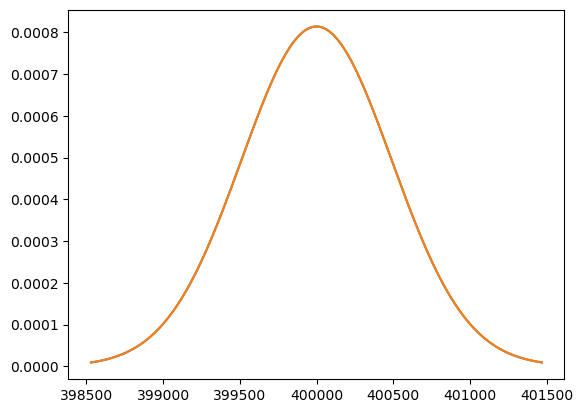

In [39]:
#Die Wahrscheinlichkeit, dass höchstens 399.500 von 1 Million Nutzern die Benachrichtigung öffnen (bei einer Erfolgsquote von 40 %).
from math import sqrt
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

def linspace(start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range(num):
        result.append(start + step * i)
    return result
 
n = 1000000
p = 0.4

left = int(n * p - 3 * sqrt(n * p * (1 - p)))
right = int(n * p + 3 * sqrt(n * p * (1 - p)))

x = list(range(max(0, left), right))

ax = plt.subplot()

ax.plot(x, binom.pmf(x, n, p))

mu = n * p
sigma = sqrt(n * p * (1 - p))

x = linspace(left, right, 100)

ax.plot(x, norm.pdf(x, mu, sigma))
plt.show()


Wie in der Grafik zu sehen ist, konzentriert sich der Großteil der Werte um etwa 400.000 Nutzer.

In [40]:
distr = st.norm(mu, sigma)

result = distr.cdf(399500)
print(result)

0.15371708296369768


Die ermittelte Wahrscheinlichkeit, dass höchstens 399.500 von einer Million Nutzern die Benachrichtigung öffnen, liegt bei etwa 15 %.

# Gesamtfazit

Im Rahmen dieser Untersuchung wurden alle zu Beginn geplanten Schritte erfolgreich durchgeführt:

    - Datenexploration: Einlesen und erste Analyse der bereitgestellten Informationen.
    - Datenbereinigung: Bearbeitung von fehlenden Werten und Duplikaten sowie Anpassung der Datenformate.
    - Explorative Datenanalyse (EDA): Untersuchung der häufigsten Werte in Bezug auf Städte, Alter der Nutzer sowie Dauer und Distanz der Fahrten.
    - Datenaggregation: Zusammenführung der Nutzerdaten und Aufteilung in zwei Gruppen (mit und ohne Abonnement), um Unterschiede zu visualisieren und detaillierter zu analysieren.
    - Hypothesenprüfung: Statistische Auswertung der aufgestellten Geschäftshypothesen.
    - Wahrscheinlichkeitsverteilungen: Erstellung von Modellen zur Unterstützung strategischer Geschäftsentscheidungen.

Hauptergebnisse der Hypothesenprüfung:
    1. Fahrtdauer: Die Hypothese, dass die durchschnittliche Fahrtdauer von Nutzern mit Abonnement der von Nutzern ohne Abonnement entspricht, wurde verworfen. Es wurde statistisch bestätigt, dass Abonnenten im Durchschnitt länger fahren.
    2. Fahrtdistanz: Die Hypothese, dass die durchschnittliche Fahrtdistanz von Nutzern mit Abonnement 3130 Meter nicht überschreitet, konnte nicht verworfen werden. Die Fahrten liegen im optimalen Bereich zur Verschleißminderung der Geräte.
    3. Umsatz: Die Hypothese, dass der Umsatz von Nutzern mit und ohne Abonnement gleich ist, wurde verworfen. Die Analyse zeigt, dass Kunden mit Abonnement einen höheren monatlichen Umsatz für den Service generieren.